In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC Taxi Analytics Assignment")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 01:26:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [6]:
yellow_path = "taxi_data/yellow_tripdata_2026-01.parquet"
green_path = "taxi_data/green_tripdata_2026-01.parquet"

yellow_df = spark.read.parquet(yellow_path)
green_df = spark.read.parquet(green_path)

In [8]:
yellow_df.printSchema()
green_df.printSchema()

yellow_df.show(5, truncate=False)
green_df.show(5, truncate=False)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: ti

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|2       |2026-01-01 00:54:04 |2026-01-01 00:59:37  |1              |0.97         |1         |N                 |239         |238 

In [11]:
print(yellow_df.columns)
print(green_df.columns)

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']
['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'cbd_congestion_fee']


In [16]:
# Note: we only have to look at the datetime columns because the PU/DO locations are already standardized 
yellow_standard_df = yellow_df.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime").withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")
green_standard_df = green_df.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime").withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")

In [20]:
# Combining the two datasets
from pyspark.sql.functions import lit

# Add a label column
y_labeled_df = yellow_standard_df.withColumn("taxi_type", lit("yellow"))
g_labeled_df = green_standard_df.withColumn("taxi_type", lit("green"))

# Combine the datasets
combined = y_labeled_df.unionByName(g_labeled_df, allowMissingColumns=True)

print(f"Total combined trips: {combined_df.count()}")

Total combined trips: 3765161


In [29]:
# Clean the combined data
from pyspark.sql.functions import col, unix_timestamp

df = combined \
    .dropna(subset=["pickup_datetime", "dropoff_datetime"]) \
    .filter(col("trip_distance") > 0) \
    .filter(col("fare_amount") >= 0) \
    .filter(col("total_amount") >= 0) \
    .filter(col("dropoff_datetime") > col("pickup_datetime")) \
    .filter((unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))) <= 86400)

df.count()
# 3557037 "rides" after cleaning

3557037

In [30]:
# Question 1: Which taxi type had more trips?
trip_count = df.groupBy("taxi_type").count().orderBy("count", ascending=False)
trip_count.show()

[Stage 28:===================>                                      (1 + 2) / 3]

+---------+-------+
|taxi_type|  count|
+---------+-------+
|   yellow|3518128|
|    green|  38909|
+---------+-------+



In [34]:
# Question 2: Average fare for each type
from pyspark.sql.functions import avg
avg_fare = df.groupBy("taxi_type").avg("fare_amount")
avg_fare.show()

[Stage 34:===================>                                      (1 + 2) / 3]

+---------+------------------+
|taxi_type|  avg(fare_amount)|
+---------+------------------+
|   yellow| 21.08260282173478|
|    green|16.003356806908457|
+---------+------------------+



In [37]:
# Question 3: Average distance trip for each type
avg_dist = df.groupBy("taxi_type").avg("trip_distance")
avg_dist.show()

+---------+------------------+
|taxi_type|avg(trip_distance)|
+---------+------------------+
|   yellow| 6.757001624157525|
|    green| 12.98990593435966|
+---------+------------------+



In [54]:
# Question 4: Hour of the day with most pickups
from pyspark.sql.functions import hour
hours_df = df.withColumn("pickup_hour", hour("pickup_datetime")).groupBy("pickup_hour").count().orderBy("count", ascending=False)
# withColumn,groupBy: groups only the hour from "pickup_datetime" and gives the name "pickup_hour"
# count,orderBy: gets the counts for each hour and sorts them
hours_df.show(24)

+-----------+------+
|pickup_hour| count|
+-----------+------+
|         18|232570|
|         17|224277|
|         15|216305|
|         19|211118|
|         20|208072|
|         21|207428|
|         16|206485|
|         14|202317|
|         13|190970|
|         22|190251|
|         12|183146|
|         11|167923|
|         10|158111|
|          9|154087|
|         23|148822|
|          8|146020|
|          7|112027|
|          0|109013|
|          1| 75623|
|          6| 62649|
|          2| 52470|
|          3| 37491|
|          5| 32070|
|          4| 27792|
+-----------+------+



In [55]:
# Question 8: predict fare (train the model)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, unix_timestamp, hour

# Create duration and hour columns to be additional features
ml_df = df \
    .withColumn("trip_duration_mins", (unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))) / 60.0) \
    .withColumn("pickup_hour", hour(col("pickup_datetime")))

# Specify features/target
feature_cols = ["trip_distance", "passenger_count", "trip_duration_mins", "pickup_hour"]
ml_df = ml_df.select(feature_cols + ["fare_amount"]).dropna()

# Split data (80/20 train/test)
train_data, test_data = ml_df.randomSplit([0.8, 0.2], seed=42)

# Assemble feature vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Initialize random forest
rf = RandomForestRegressor(featuresCol="features", labelCol="fare_amount", seed=42)

# Train
pipeline = Pipeline(stages=[assembler, rf])
model = pipeline.fit(train_data)

26/05/24 02:28:04 WARN MemoryStore: Not enough space to cache rdd_437_0 in memory! (computed 138.7 MiB so far)
26/05/24 02:28:04 WARN BlockManager: Persisting block rdd_437_0 to disk instead.
                                                                                

In [43]:
# Question 8: predict fare (Show the RMSE)
from pyspark.ml.evaluation import RegressionEvaluator

# Preds for train and test
train_preds = model.transform(train_data)
test_preds = model.transform(test_data)

# Calc RMSE
evaluator = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction", metricName="rmse")
train_rmse = evaluator.evaluate(train_preds)
test_rmse = evaluator.evaluate(test_preds)

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse:.2f}")

[Stage 66:======================================>                   (2 + 1) / 3]

Training RMSE: 7.89
Testing RMSE: 8.28


In [46]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


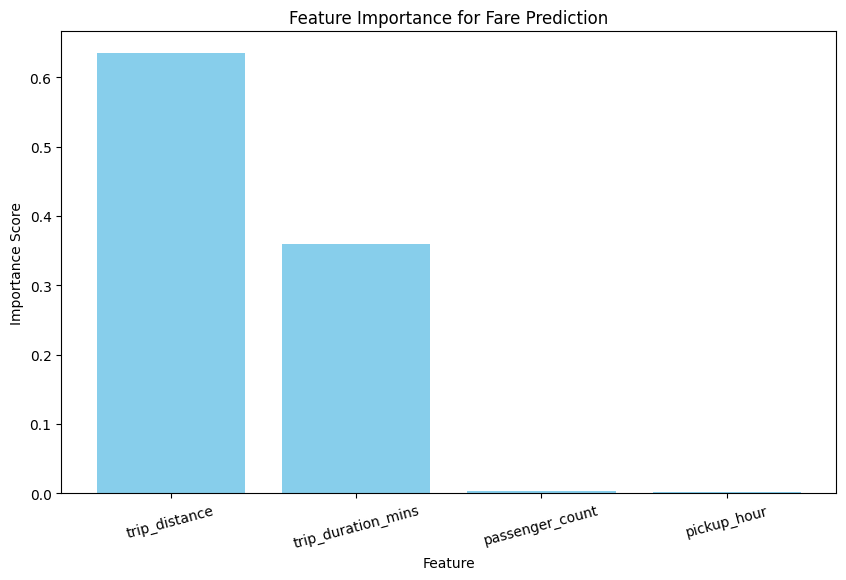

In [47]:
# Question 8: predict fare (Plot the feature importance)
import pandas as pd
import matplotlib.pyplot as plt

# Extract the trained model, calc importance vector
rf_model = model.stages[-1]
importances = rf_model.featureImportances.toArray()

# Create importance df (map features to their importance)
feature_cols = ["trip_distance", "passenger_count", "trip_duration_mins", "pickup_hour"]
importance_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df["Feature"], importance_df["Importance"], color='skyblue')
plt.title("Feature Importance for Fare Prediction")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=15)
plt.show()

# Note: Used AI to generate this ploting code to make it look nice. My idea to try and plot the importance, though.  

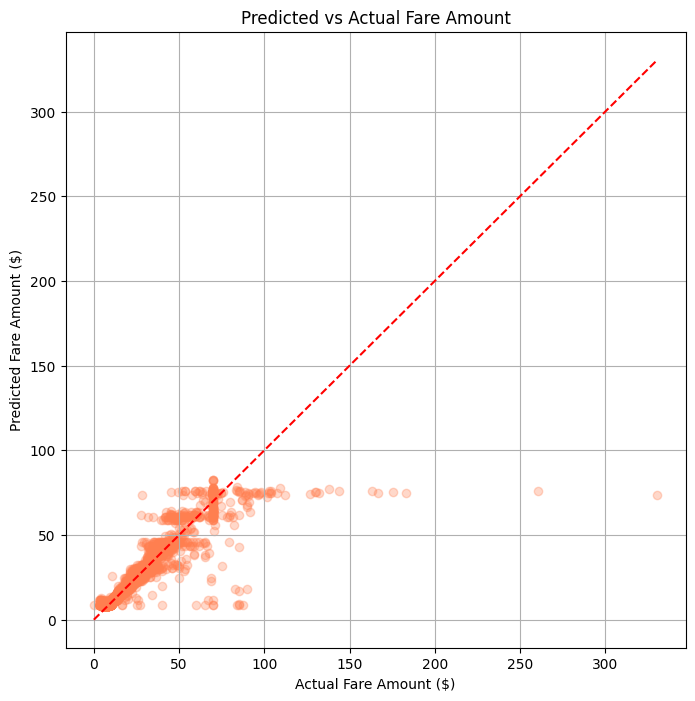

In [49]:
# Question 8: predict fare (Plot real fare vs predicted fare)
# Only use 1% of data (still ~30,000 data points) for visualization
plot_data = test_predictions.select("fare_amount", "prediction").sample(fraction=0.01, seed=42).toPandas()

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(plot_data["fare_amount"], plot_data["prediction"], alpha=0.3, color='coral')

# Add a reference line for a "perfect" prediction
plt.plot([plot_data["fare_amount"].min(), plot_data["fare_amount"].max()], 
         [plot_data["fare_amount"].min(), plot_data["fare_amount"].max()], 
         color='red', linestyle='--')

plt.title("Predicted vs Actual Fare Amount")
plt.xlabel("Actual Fare Amount ($)")
plt.ylabel("Predicted Fare Amount ($)")
plt.grid(True)

# Save plot locally 
plt.savefig("predicted_vs_actual_fare.png")
plt.show()

# Note: Also used AI to generate plotting code so it could look as nice as it does. 

In [53]:
# upload results to s3 bucket
output_base = "s3_output"

trip_count.write.mode("overwrite").parquet(f"{output_base}/trip_count")
avg_fare.write.mode("overwrite").parquet(f"{output_base}/avg_fare")
avg_dist.write.mode("overwrite").parquet(f"{output_base}/avg_dist")
hours_df.write.mode("overwrite").parquet(f"{output_base}/hour_df")